In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [10]:
br=pd.read_csv('C:\\Users\\Sayed Al Rafi\\Documents\\Data Desktop\\Data_Analysis\\ML project\\Breast Cancer Prediction(PJ 1)\\Breast-Cancer-Detection-using-Machine-Learning-With-App\\raw_data\\breast cancer.csv')

In [11]:
br.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [12]:
br.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

Target Variable explain

In [13]:
br['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

 Target Variable Explanation

The target variable in this dataset is `diagnosis`, which indicates whether a breast tumor is benign or malignant.

- `B` = Benign
- `M` = Malignant

In the dataset, the target distribution is:
- `B`: 357 cases
- `M`: 212 cases

This makes the problem a binary classification task. The model is trained to predict `diagnosis` from the input features extracted from tumor images, such as radius, texture, perimeter, and area.

Because the classes are slightly imbalanced, evaluation should include metrics beyond accuracy, such as precision, recall, F1-score, and the confusion matrix.

## Metrics of the dataset imp 6 question

In [14]:
br.shape

(569, 33)

In [15]:
br.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [16]:
br.duplicated().sum()

np.int64(0)

In [17]:
br.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

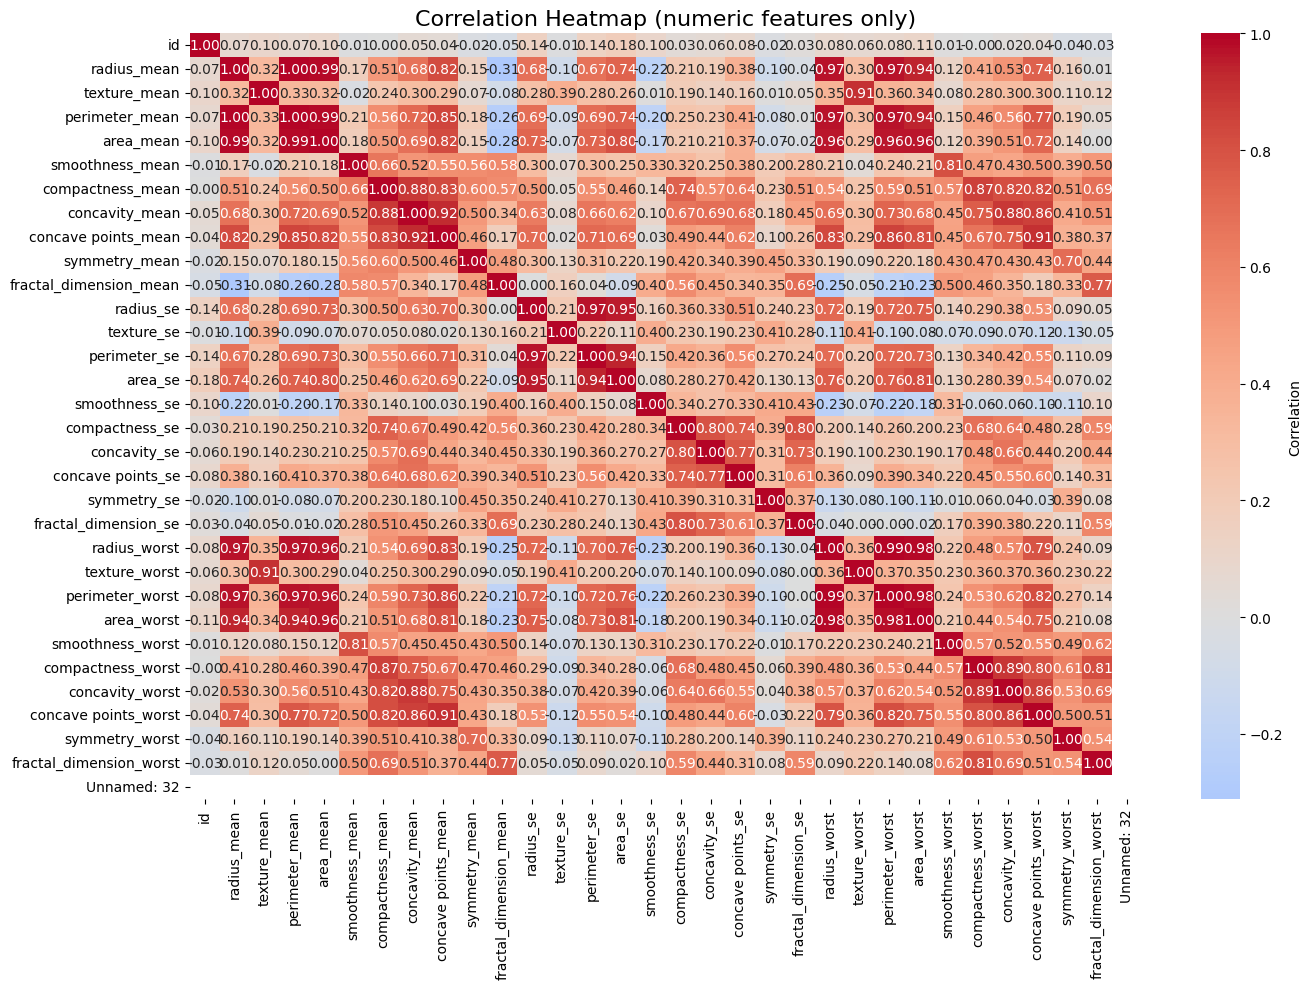

In [18]:
numeric_corr = br.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap (numeric features only)', fontsize=16)
plt.tight_layout()
plt.show()

In [20]:
br.drop(columns=['Unnamed: 32'], axis=1,inplace=True)

In [21]:
br.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## Encoding Categorical Value

In [22]:
br['diagnosis'] = br['diagnosis'].map({'M':1,'B':0})

In [23]:
br.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Spltting data into Trainng and test

In [24]:
x=br.drop(columns=['diagnosis'],axis=1)
y=br['diagnosis']

In [27]:
x.shape

(569, 31)

In [29]:
x_test,x_train,y_test,y_train = train_test_split(x,y,test_size=0.2,random_state=2)

# Feature Scaling

In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [32]:
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)


# Training Model
This problem is a classification problem so we are going to use the Logistic Regression model to perform the prediction

In [34]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train) 

LogisticRegression()

In [ ]:
import pickle
from pathlib import Path

model_dir = Path('..') / 'model'
model_dir.mkdir(exist_ok=True)

with open(model_dir / 'base_model.pkl', 'wb') as file:
    pickle.dump(lr, file)

In [35]:
y_pred=lr.predict(x_test)

In [37]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.967032967032967

## Prediction System

In [ ]:
input_text=(-0.22113181,  0.82993333,  1.41380849,  0.87579342,  0.75772485,
        0.7147203 ,  1.36344147,  0.81911538,  0.68080163,  0.32352939,
        0.2485258 ,  0.58266418, -0.32516484,  0.33546888,  0.63173316,
       -0.49934293,  1.56191362,  0.16132205, -0.16850851, -0.59779178,
        0.6694212 ,  1.30228984,  1.47946329,  1.16948048,  1.2100149 ,
        1.14282204,  2.96420707,  1.75078692,  1.06666888,  0.5676593 ,
        2.75263383)
np_df=np.asarray(input_text)
predection=lr.predict(np_df.reshape(1,-1))

if predection[0]==1:
    print("The person is having breast cancer")
else:
    print("The person is not having breast cancer")

The person is having breast cancer


In [39]:
x_train[19]

array([-0.22113181,  0.82993333,  1.41380849,  0.87579342,  0.75772485,
        0.7147203 ,  1.36344147,  0.81911538,  0.68080163,  0.32352939,
        0.2485258 ,  0.58266418, -0.32516484,  0.33546888,  0.63173316,
       -0.49934293,  1.56191362,  0.16132205, -0.16850851, -0.59779178,
        0.6694212 ,  1.30228984,  1.47946329,  1.16948048,  1.2100149 ,
        1.14282204,  2.96420707,  1.75078692,  1.06666888,  0.5676593 ,
        2.75263383])